# Task 7: Basic Sales Summary from SQLite Database

In [1]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

# Step 1: Connect to (or create) the SQLite database
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

# Step 2: Create the 'sales' table and insert some dummy data
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
''')

# Optional: Clear old data for repeatability
cursor.execute('DELETE FROM sales')

# Insert some sample records
sample_data = [
    ('Apples', 10, 0.5),
    ('Bananas', 20, 0.3),
    ('Oranges', 15, 0.4),
    ('Apples', 5, 0.5),
    ('Bananas', 10, 0.3),
    ('Oranges', 5, 0.4),
]
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()


In [3]:

# Step 3: Query total quantity and revenue per product
query = '''
    SELECT 
        product, 
        SUM(quantity) AS total_qty, 
        ROUND(SUM(quantity * price), 2) AS revenue
    FROM sales
    GROUP BY product
'''
df = pd.read_sql_query(query, conn)


In [4]:

# Step 4: Display the result using print
print("Sales Summary:")
print(df)


Sales Summary:
   product  total_qty  revenue
0   Apples         15      7.5
1  Bananas         30      9.0
2  Oranges         20      8.0


<Figure size 800x500 with 0 Axes>

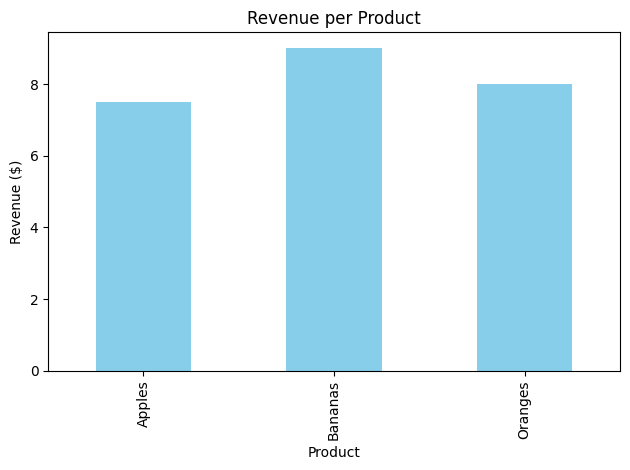

In [5]:

# Step 5: Plot revenue per product as a bar chart
plt.figure(figsize=(8, 5))
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title('Revenue per Product')
plt.ylabel('Revenue ($)')
plt.xlabel('Product')
plt.tight_layout()
plt.savefig('sales_chart.png')  # Optional: save the chart as an image
plt.show()


In [6]:

# Close the connection
conn.close()
